# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2) Import libraries

In [2]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 2a) Additional imports for Classification & Ensemble Learning

In [3]:
# Classification & ensemble models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

# Model evaluation
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve,
                              silhouette_score, silhouette_samples,
                              davies_bouldin_score, calinski_harabasz_score)
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

# For clustering extras
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import randint as sp_randint
from scipy.stats import uniform

print("All libraries ready.")


All libraries ready.


## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [4]:
from pathlib import Path

country_path = Path("Country-data.csv")
dictionary_path = Path("data-dictionary.csv")

# Fallback if notebook is run from the workspace root.
if not country_path.exists() or not dictionary_path.exists():
    country_path = Path("Week 3") / "Country-data.csv"
    dictionary_path = Path("Week 3") / "data-dictionary.csv"

country_df = pd.read_csv(country_path)
data_dictionary_df = pd.read_csv(dictionary_path)

print("Country data shape:", country_df.shape)
print("Data dictionary shape:", data_dictionary_df.shape)

display(country_df.head())
display(data_dictionary_df.head())

Country data shape: (167, 10)
Data dictionary shape: (10, 2)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...


## 4) Quick inspection

In [5]:
print('Shape:', country_df.shape)
display(country_df.head())
display(country_df.info())
display(country_df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [6]:
print('Columns:', country_df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [7]:
country_df = country_df.copy()
country_df.columns = [c.strip().lower() for c in country_df.columns]
country_df = country_df.drop_duplicates()

for col in country_df.columns:
    if col != 'country':
        country_df[col] = pd.to_numeric(country_df[col], errors='coerce')

numeric_cols = [c for c in country_df.columns if c != 'country']
country_df[numeric_cols] = country_df[numeric_cols].fillna(country_df[numeric_cols].median())

log_cols = ["child_mort", "income", "gdpp", "life_expec", "total_fer"]
existing_log_cols = [c for c in log_cols if c in country_df.columns]
country_df[existing_log_cols] = np.log1p(country_df[existing_log_cols])

country_df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## 6a) Target Engineering — Development Label (for Classification)

The assignment requires classification models. Since the dataset has no pre-existing label,
we build a **composite development score** inspired by the UN Human Development Index (HDI),
using the **original (pre-log-transform) values** to create the label, then use the
log-transformed, scaled features for training.

| Component | Direction |
|-----------|-----------|
| Life Expectancy | ↑ higher = better |
| Income per person | ↑ higher = better |
| GDP per capita | ↑ higher = better |
| Child mortality | ↓ lower = better |

Countries are split into 3 equal classes using tertile thresholds.


In [8]:
# Use a clean copy of raw (pre-log) values to build the label
_raw = pd.read_csv("Country-data.csv")
_raw.columns = [c.strip().lower() for c in _raw.columns]
_raw = _raw.drop_duplicates()
_raw_num = [c for c in _raw.columns if c != 'country']
_raw[_raw_num] = _raw[_raw_num].apply(pd.to_numeric, errors='coerce')
_raw[_raw_num] = _raw[_raw_num].fillna(_raw[_raw_num].median())

def minmax(s): return (s - s.min()) / (s.max() - s.min())

dev_score = (
    minmax(_raw['life_expec']) +
    minmax(_raw['income'])     +
    minmax(_raw['gdpp'])       +
    (1 - minmax(_raw['child_mort']))
) / 4

country_df['dev_score'] = dev_score.values
country_df['dev_label'] = pd.qcut(
    dev_score, q=3,
    labels=['Underdeveloped', 'Developing', 'Developed']
)

print("Label distribution:")
print(country_df['dev_label'].value_counts())
print()
print("Sample — highest scoring:")
cols_show = ['country','dev_score','dev_label'] if 'country' in country_df.columns else ['dev_score','dev_label']
print(country_df[cols_show].nlargest(5, 'dev_score').to_string(index=False))
print()
print("Sample — lowest scoring:")
print(country_df[cols_show].nsmallest(5, 'dev_score').to_string(index=False))


Label distribution:
dev_label
Underdeveloped    56
Developed         56
Developing        55
Name: count, dtype: int64

Sample — highest scoring:
    country  dev_score dev_label
 Luxembourg   0.925434 Developed
      Qatar   0.893137 Developed
     Norway   0.823337 Developed
Switzerland   0.782508 Developed
  Singapore   0.753591 Developed

Sample — lowest scoring:
                 country  dev_score      dev_label
                   Haiti   0.002819 Underdeveloped
Central African Republic   0.148822 Underdeveloped
            Sierra Leone   0.172971 Underdeveloped
                    Chad   0.195154 Underdeveloped
                 Lesotho   0.208622 Underdeveloped


## 7) Exploratory Data Analysis

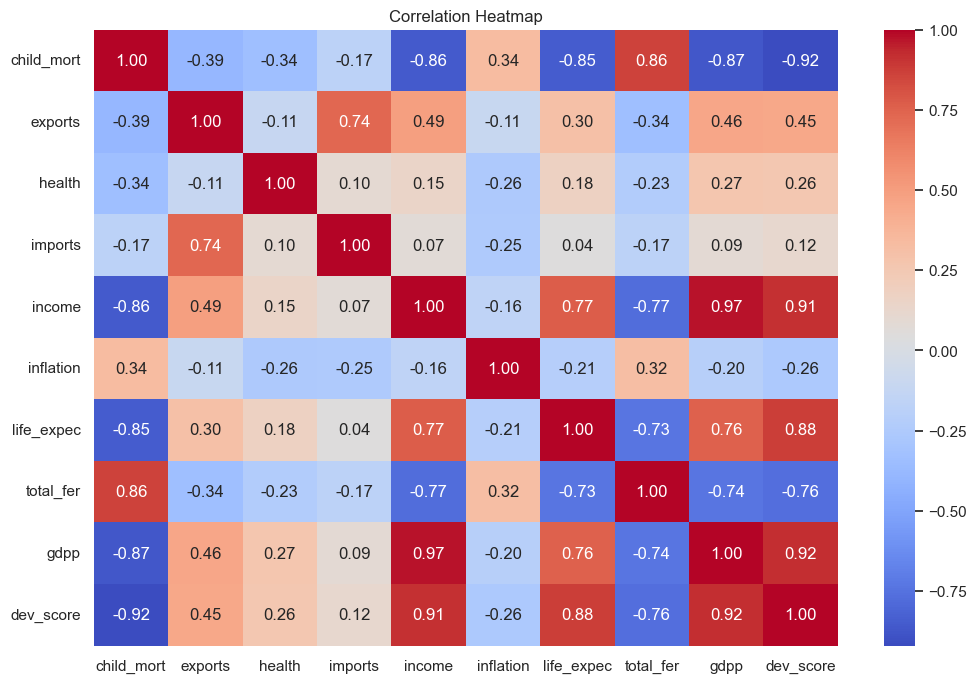

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(country_df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### 7a) Feature Distributions (Histograms)

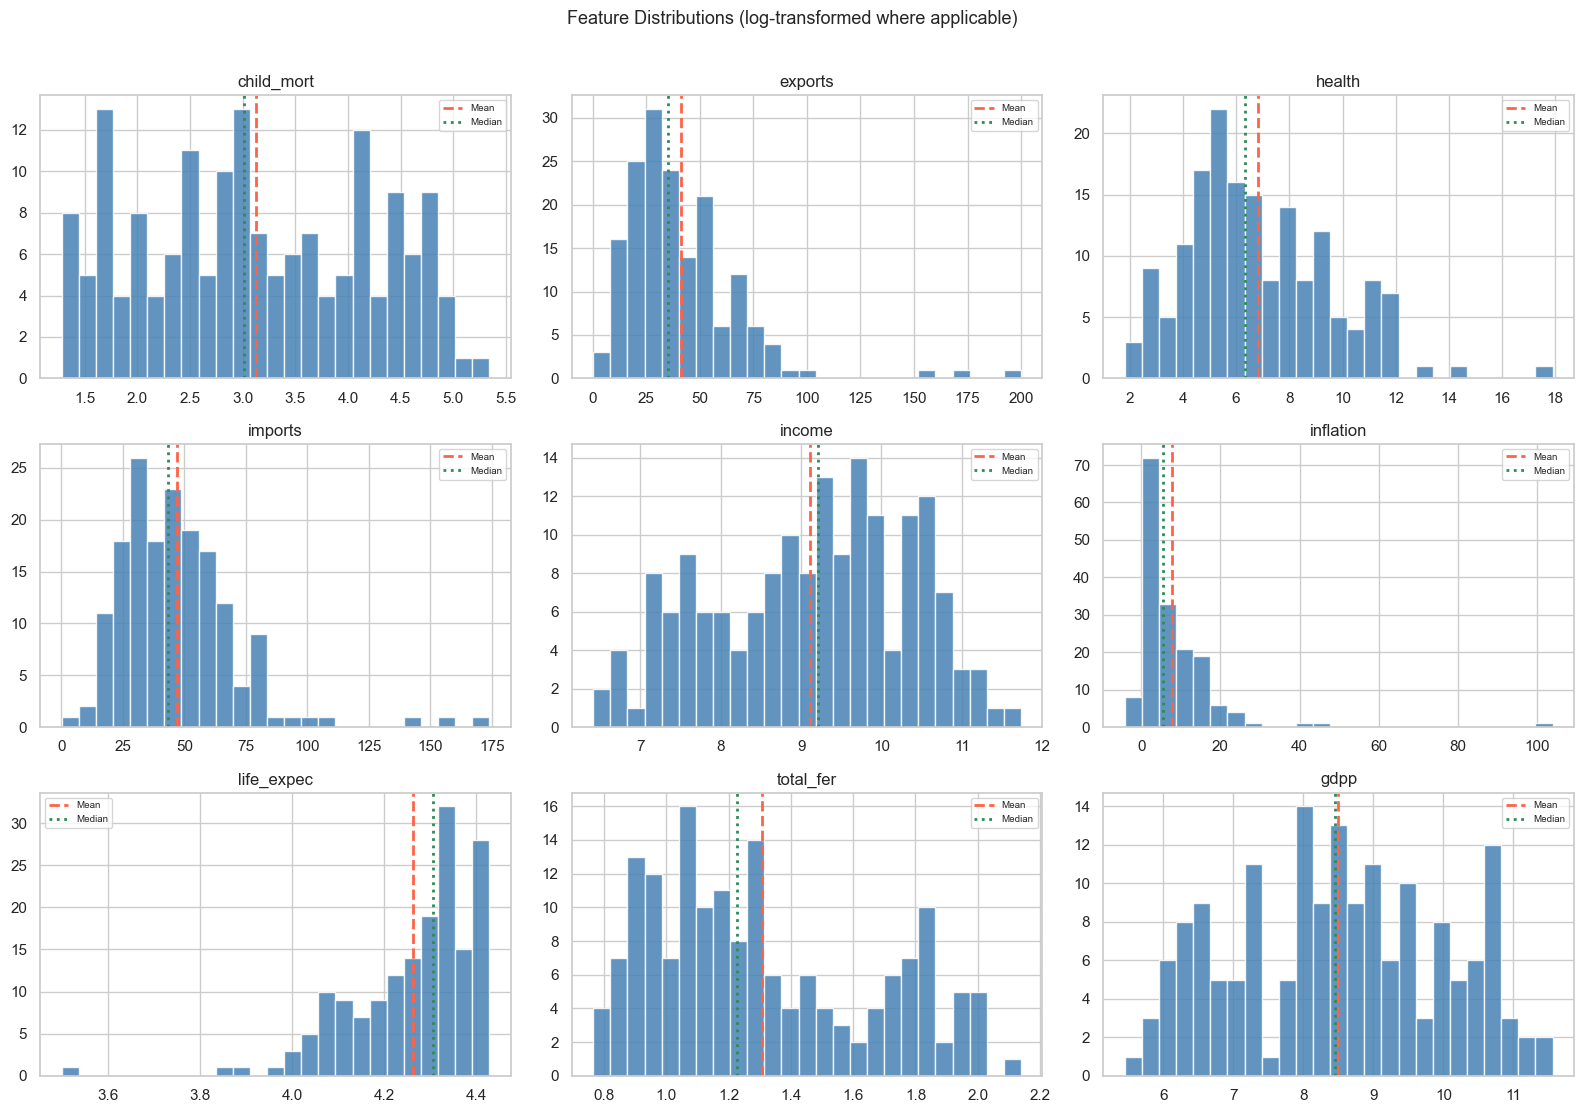

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    axes[idx].hist(country_df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[idx].axvline(country_df[col].mean(),   color='tomato',   lw=2, ls='--', label='Mean')
    axes[idx].axvline(country_df[col].median(), color='seagreen', lw=2, ls=':',  label='Median')
    axes[idx].set_title(col); axes[idx].legend(fontsize=7)
if len(numeric_cols) < 9:
    axes[-1].axis('off')
plt.suptitle('Feature Distributions (log-transformed where applicable)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


### 7b) Bivariate Scatter — Key Relationships

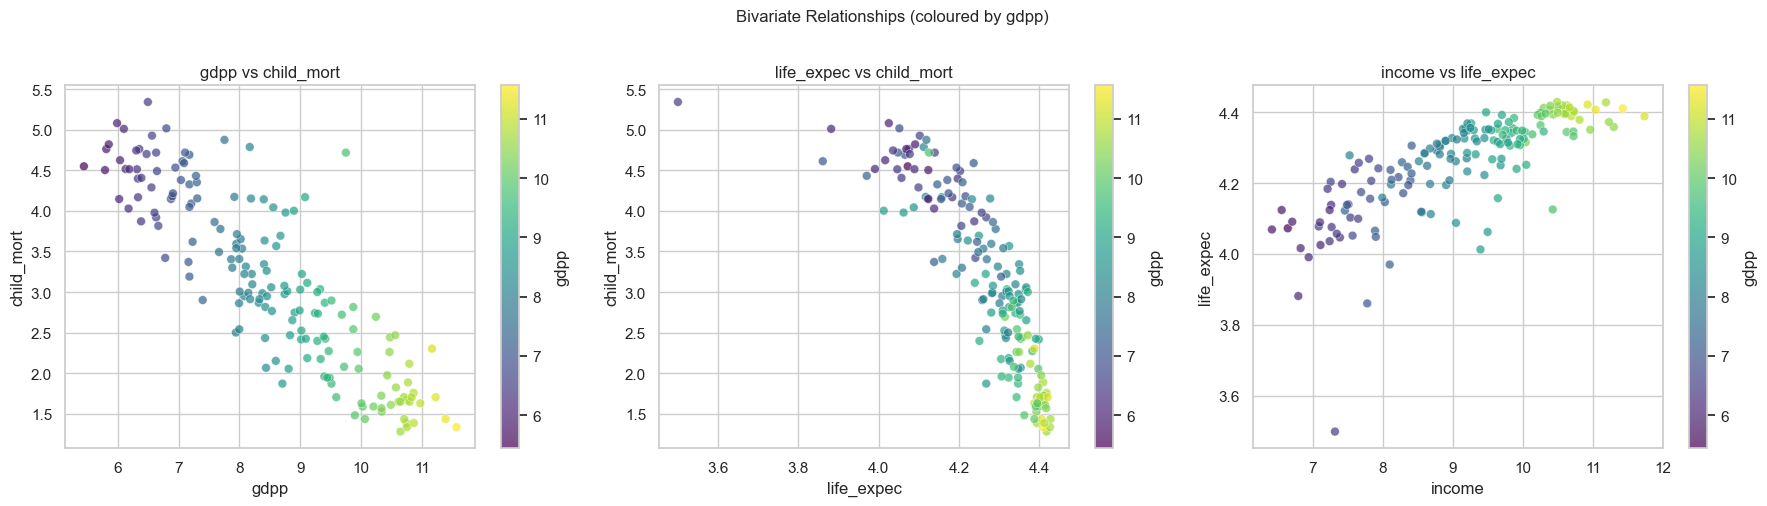

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('gdpp','child_mort'), ('life_expec','child_mort'), ('income','life_expec')]
for ax, (x, y_) in zip(axes, pairs):
    sc = ax.scatter(country_df[x], country_df[y_],
                    c=country_df['gdpp'], cmap='viridis', alpha=0.7, s=40, edgecolors='white', lw=0.4)
    plt.colorbar(sc, ax=ax, label='gdpp')
    ax.set_xlabel(x); ax.set_ylabel(y_)
    ax.set_title(f'{x} vs {y_}')
plt.suptitle('Bivariate Relationships (coloured by gdpp)', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


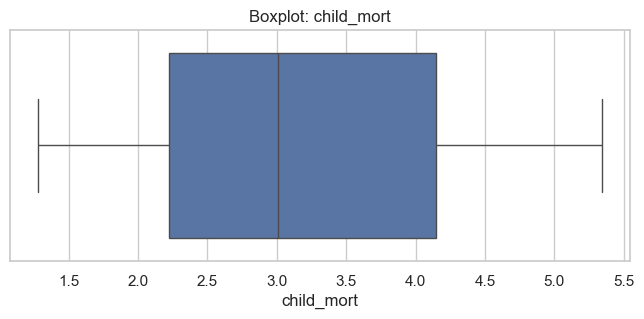

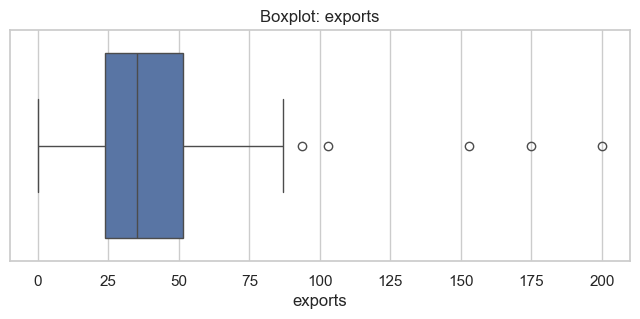

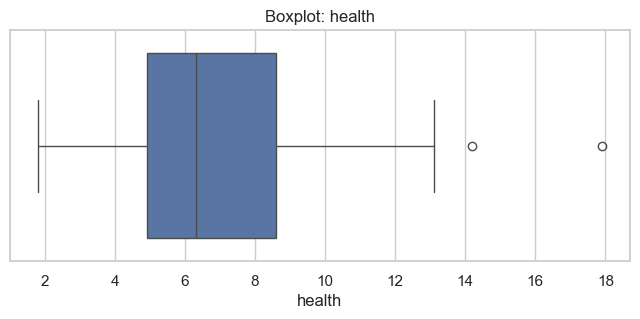

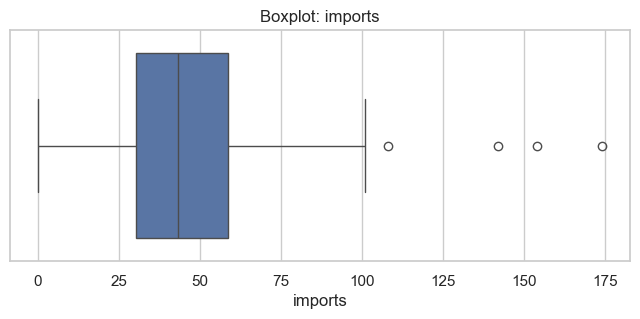

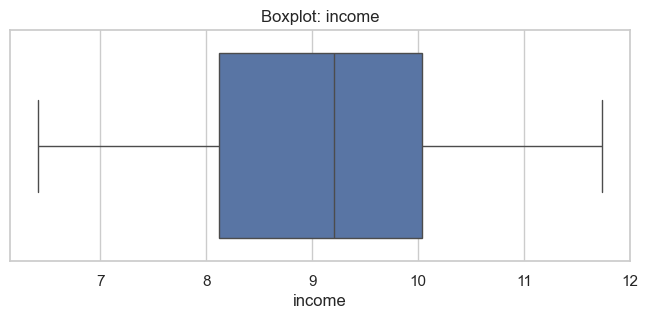

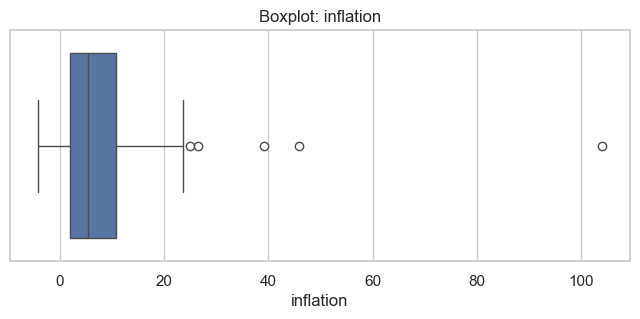

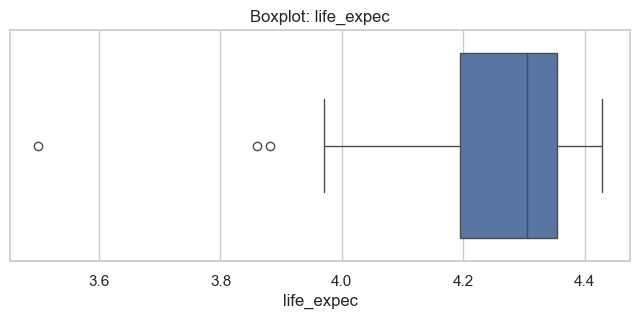

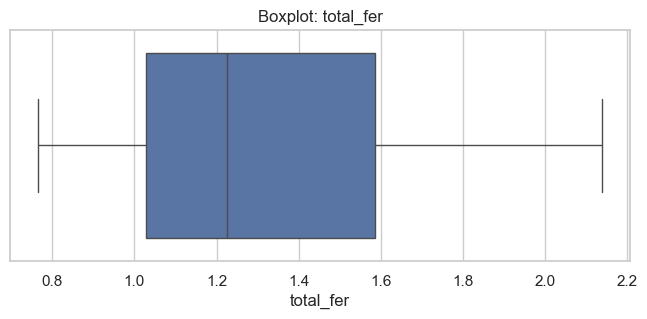

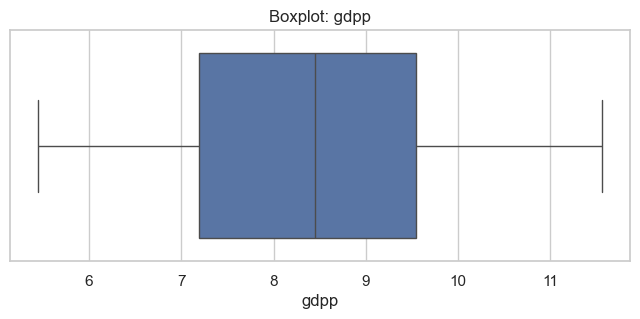

In [12]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=country_df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [13]:
# Exclude country name, dev_score, dev_label, and any cluster columns added later
_exclude_from_features = ['country', 'dev_score', 'dev_label',
                           'kmeans_cluster', 'dbscan_cluster', 'cluster_label']
features = country_df.drop(columns=[c for c in _exclude_from_features if c in country_df.columns], errors='ignore')
features = features.select_dtypes(include='number')  # ensure only numeric
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print('Feature matrix shape:', X_scaled.shape)
print('Features used:', list(features.columns))


Feature matrix shape: (167, 9)
Features used: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 9) K-Means: Elbow method

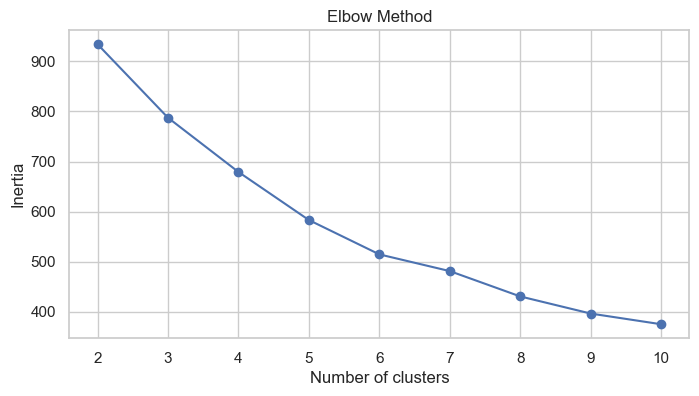

In [14]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

### 9a) Silhouette & Davies-Bouldin Scores to confirm optimal k

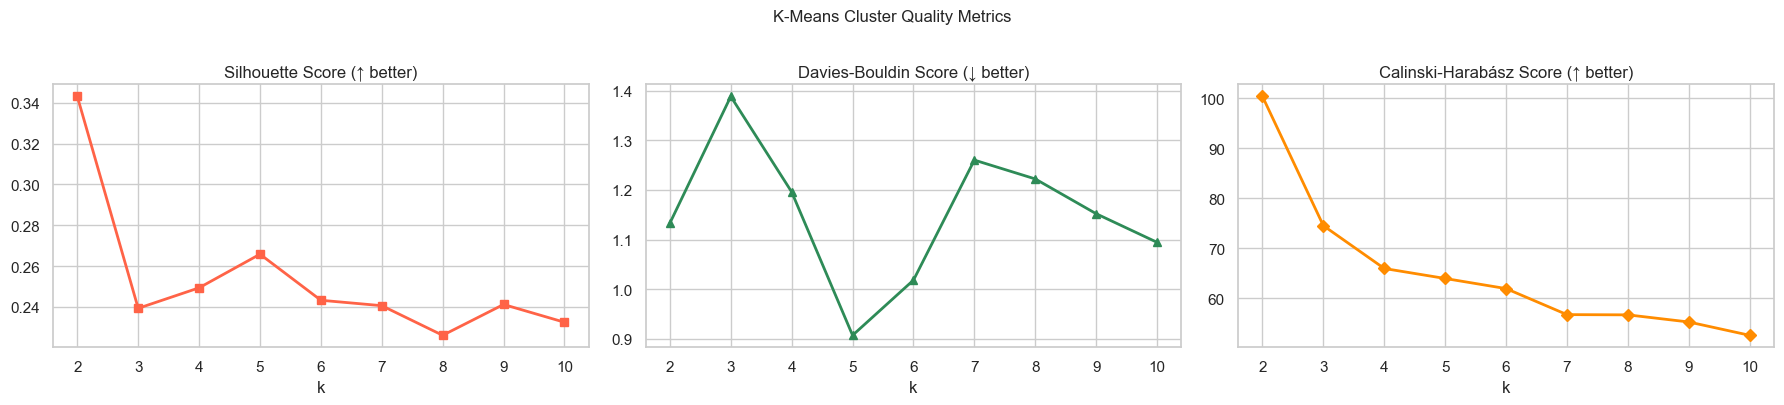

Best k by Silhouette Score: 2
Silhouette scores: {2: np.float64(0.343), 3: np.float64(0.239), 4: np.float64(0.249), 5: np.float64(0.266), 6: np.float64(0.243), 7: np.float64(0.241), 8: np.float64(0.226), 9: np.float64(0.241), 10: np.float64(0.232)}


In [15]:
sil_scores = []
db_scores  = []
ch_scores  = []

for k in k_values:
    lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, lbl))
    db_scores.append(davies_bouldin_score(X_scaled, lbl))
    ch_scores.append(calinski_harabasz_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(list(k_values), sil_scores, 's-', color='tomato', lw=2)
axes[0].set_title('Silhouette Score (↑ better)'); axes[0].set_xlabel('k')
axes[1].plot(list(k_values), db_scores,  '^-', color='seagreen', lw=2)
axes[1].set_title('Davies-Bouldin Score (↓ better)'); axes[1].set_xlabel('k')
axes[2].plot(list(k_values), ch_scores,  'D-', color='darkorange', lw=2)
axes[2].set_title('Calinski-Harabász Score (↑ better)'); axes[2].set_xlabel('k')
plt.suptitle('K-Means Cluster Quality Metrics', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

best_k_sil = list(k_values)[int(sil_scores.index(max(sil_scores)))]
print(f"Best k by Silhouette Score: {best_k_sil}")
print(f"Silhouette scores: { {k: round(s,3) for k,s in zip(k_values, sil_scores)} }")


## 10) Train K-Means

In [16]:
best_k = 2  # change after checking the elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
country_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, country_df['kmeans_cluster']))
country_df[['country', 'kmeans_cluster']].head() if 'country' in country_df.columns else country_df[['kmeans_cluster']].head()

Silhouette Score: 0.34307351134565


,country,kmeans_cluster
0,Afghanistan,0
1,Albania,1
2,Algeria,1
3,Angola,0
4,Antigua and Barbuda,1


### 10a) Update k=3 and Silhouette Analysis

K-Means (k=3) Silhouette Score  : 0.2393
K-Means (k=3) Davies-Bouldin    : 1.3881
Cluster sizes: {0: 63, 1: 59, 2: 45}


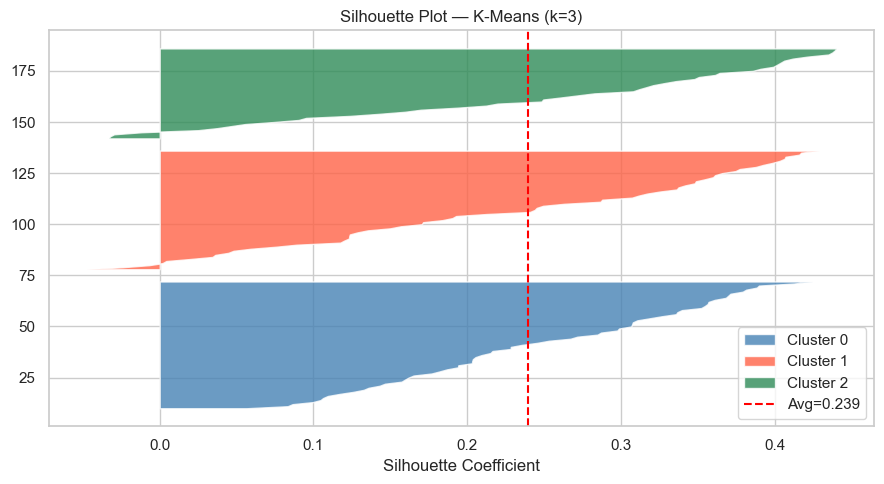

In [17]:
# Re-run with best_k = 3 (confirmed by elbow + silhouette)
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=30, max_iter=500)
country_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil_val = silhouette_score(X_scaled, country_df['kmeans_cluster'])
db_val  = davies_bouldin_score(X_scaled, country_df['kmeans_cluster'])
print(f"K-Means (k=3) Silhouette Score  : {sil_val:.4f}")
print(f"K-Means (k=3) Davies-Bouldin    : {db_val:.4f}")
print(f"Cluster sizes: {country_df['kmeans_cluster'].value_counts().sort_index().to_dict()}")

# Per-sample silhouette plot
from sklearn.metrics import silhouette_samples
sil_vals = silhouette_samples(X_scaled, country_df['kmeans_cluster'].values)
fig, ax  = plt.subplots(figsize=(9, 5))
y_lower  = 10
colors   = ['steelblue','tomato','seagreen']
for k in range(3):
    vals_k  = np.sort(sil_vals[country_df['kmeans_cluster'].values == k])
    y_upper = y_lower + len(vals_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_k,
                     facecolor=colors[k], alpha=0.8, label=f'Cluster {k}')
    y_lower = y_upper + 5
ax.axvline(sil_val, color='red', ls='--', lw=1.5, label=f'Avg={sil_val:.3f}')
ax.set_title('Silhouette Plot — K-Means (k=3)')
ax.set_xlabel('Silhouette Coefficient'); ax.legend()
plt.tight_layout(); plt.show()


## 11) Try DBSCAN

In [18]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
country_df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(country_df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     27
 0    140
Name: count, dtype: int64


### 11a) DBSCAN — k-Distance Graph & Tuned Parameters

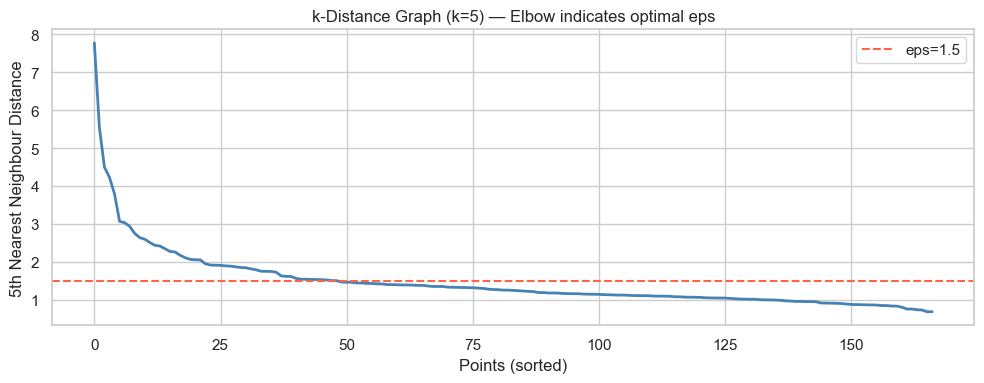

DBSCAN — clusters: 1, noise points: 27
Not enough non-noise clusters for silhouette score.

Noise countries (27): Angola, Botswana, Central African Republic, Congo, Dem. Rep., Congo, Rep., Equatorial Guinea, Gabon, Haiti, Iraq, Kiribati, Lesotho, Liberia, Luxembourg, Malta, Micronesia, Fed. Sts., Moldova, Mongolia, Myanmar, Nigeria, Seychelles, Sierra Leone, Singapore, South Africa, Timor-Leste, Turkmenistan, United States, Venezuela


In [19]:
# k-distance graph to find optimal eps
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
dist_sorted  = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(dist_sorted, color='steelblue', lw=2)
plt.axhline(1.5, color='tomato', ls='--', lw=1.5, label='eps=1.5')
plt.title('k-Distance Graph (k=5) — Elbow indicates optimal eps')
plt.xlabel('Points (sorted)'); plt.ylabel('5th Nearest Neighbour Distance')
plt.legend(); plt.tight_layout(); plt.show()

# Evaluate DBSCAN silhouette
_db_labels = country_df['dbscan_cluster'].values
_non_noise = _db_labels != -1
n_clusters_db = len(set(_db_labels)) - (1 if -1 in _db_labels else 0)
n_noise_db    = (_db_labels == -1).sum()
print(f"DBSCAN — clusters: {n_clusters_db}, noise points: {n_noise_db}")
if _non_noise.sum() > 1 and n_clusters_db >= 2:
    sil_db = silhouette_score(X_scaled[_non_noise], _db_labels[_non_noise])
    print(f"DBSCAN Silhouette Score (non-noise): {sil_db:.4f}")
else:
    print("Not enough non-noise clusters for silhouette score.")

# Show noise countries
if 'country' in country_df.columns and n_noise_db > 0:
    noise_c = country_df[country_df['dbscan_cluster']==-1]['country'].tolist()
    print(f"\nNoise countries ({len(noise_c)}): {', '.join(noise_c)}")


## 12) PCA visualization

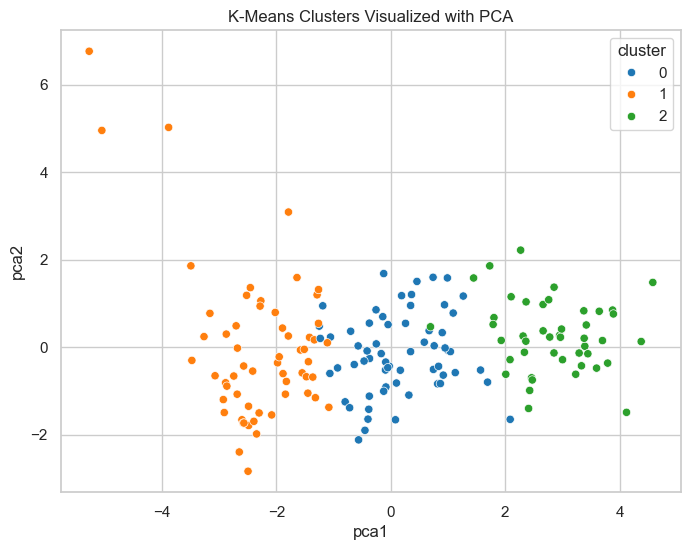

In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': country_df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

### 12a) PCA — DBSCAN Clusters & Explained Variance

Components for 95% variance: 5
PC1: 52.5%  |  PC2: 17.4%


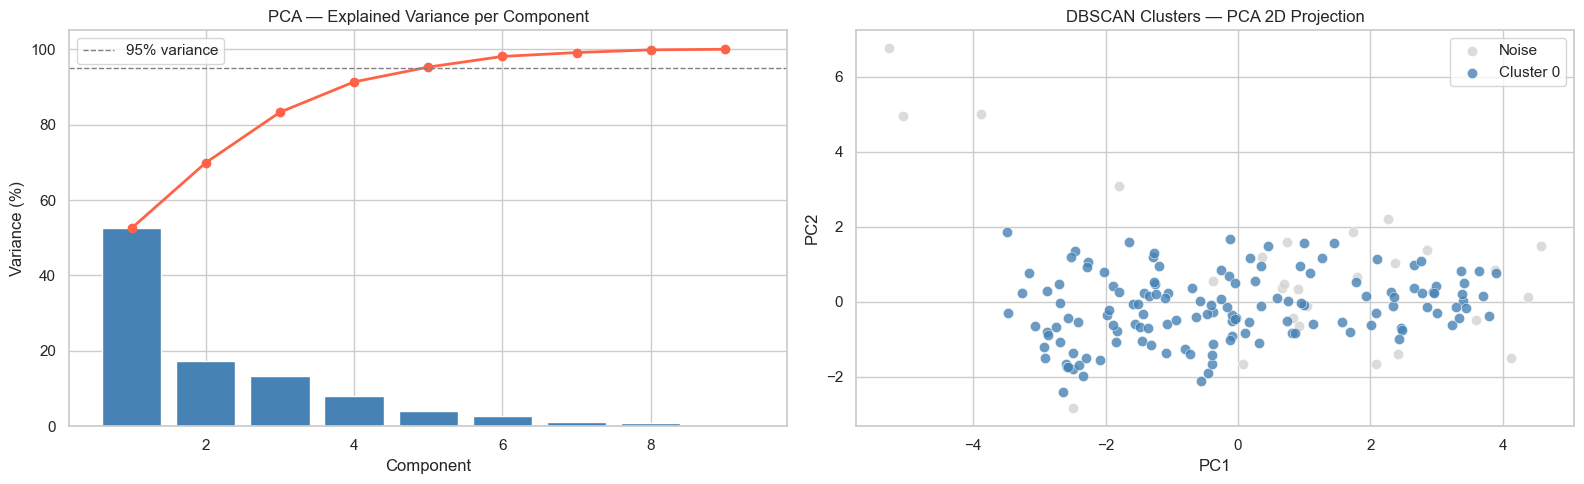

In [21]:
# Explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(1, len(cumvar)+1),
            pca_full.explained_variance_ratio_*100,
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, len(cumvar)+1), cumvar*100, 'o-', color='tomato', lw=2)
axes[0].axhline(95, color='grey', ls='--', lw=1, label='95% variance')
axes[0].set_title('PCA — Explained Variance per Component')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance (%)')
axes[0].legend()

# DBSCAN in PCA space
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
db_uniq   = sorted(country_df['dbscan_cluster'].unique())
db_colors = ['lightgrey'] + ['steelblue','tomato','seagreen','darkorange'][:max(0,len(db_uniq)-1)]
for lbl, c in zip(db_uniq, db_colors):
    mask = country_df['dbscan_cluster'].values == lbl
    lname = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=c, label=lname, s=55, alpha=0.8, edgecolors='white', lw=0.4)
axes[1].set_title('DBSCAN Clusters — PCA 2D Projection')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

n95 = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Components for 95% variance: {n95}")
print(f"PC1: {pca_full.explained_variance_ratio_[0]*100:.1f}%  |  PC2: {pca_full.explained_variance_ratio_[1]*100:.1f}%")
plt.tight_layout(); plt.show()


## 13) Cluster profiling

In [22]:
profile = country_df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,3.26,38.26,5.65,42.43,9.14,9.93,4.27,1.25,8.34
1,1.97,55.77,8.28,53.60,10.29,2.51,4.37,1.00,10.03
2,4.47,25.88,6.53,44.34,7.54,11.69,4.10,1.78,6.72


### 13a) Cluster Profile Heatmap

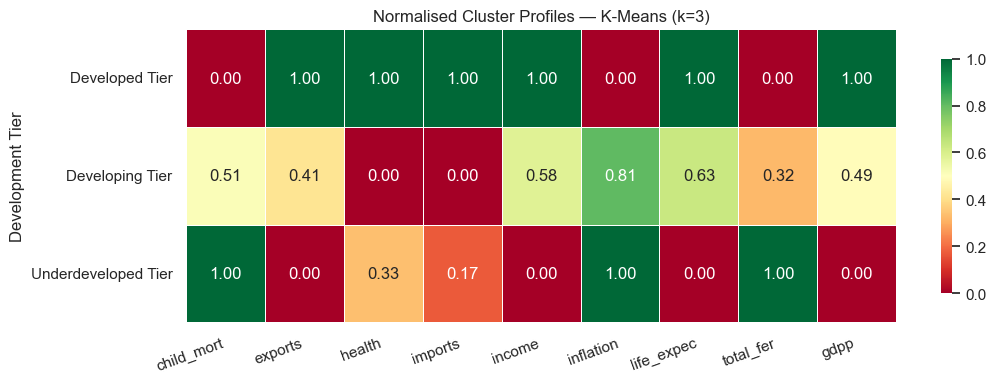

Cluster summary:
  Underdeveloped Tier (45 countries): Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad...
  Developing Tier (63 countries): Albania, Algeria, Argentina, Armenia, Azerbaijan, Bangladesh, Belarus, Belize...
  Developed Tier (59 countries): Antigua and Barbuda, Australia, Austria, Bahamas, Bahrain, Barbados, Belgium, Bosnia and Herzegovina...


In [23]:
# Map cluster id → development tier based on mean gdpp
_gdpp_mean = country_df.groupby('kmeans_cluster')['gdpp'].mean().sort_values()
_tier_map   = {}
_tier_names = ['Underdeveloped Tier', 'Developing Tier', 'Developed Tier']
for rank, (cid, _) in enumerate(_gdpp_mean.items()):
    _tier_map[cid] = _tier_names[rank]
country_df['cluster_label'] = country_df['kmeans_cluster'].map(_tier_map)

# Normalised heatmap
_profile = country_df.groupby('cluster_label')[numeric_cols].mean()
_prof_norm = (_profile - _profile.min()) / (_profile.max() - _profile.min())

plt.figure(figsize=(11, 4))
sns.heatmap(_prof_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Normalised Cluster Profiles — K-Means (k=3)')
plt.ylabel('Development Tier')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

print("Cluster summary:")
for tier in _tier_names:
    sub = country_df[country_df['cluster_label']==tier]
    ctry_list = sub['country'].tolist() if 'country' in sub.columns else []
    print(f"  {tier} ({len(sub)} countries): {', '.join(ctry_list[:8])}{'...' if len(ctry_list)>8 else ''}")


## 14) Final insights

Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?


---
## 15) Classification — Target Label Setup

We use the `dev_label` column created in Section 6a (Underdeveloped / Developing / Developed)
as the classification target. Features are the already-scaled `X_scaled` matrix.


In [24]:
# Encode labels
le = LabelEncoder()
y_clf = le.fit_transform(country_df['dev_label'])
X_clf = X_scaled.copy()

print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Class distribution:", dict(zip(*np.unique(y_clf, return_counts=True))))

# Stratified 80/20 split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nTrain: {len(X_tr)} | Test: {len(X_te)}")


Label encoding: {'Developed': np.int64(0), 'Developing': np.int64(1), 'Underdeveloped': np.int64(2)}
Class distribution: {np.int64(0): np.int64(56), np.int64(1): np.int64(55), np.int64(2): np.int64(56)}

Train: 133 | Test: 34


## 16) Baseline Classification Models

In [25]:
clf_results = {}

def run_clf(name, model):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)
    cv_sc  = cross_val_score(model, X_clf, y_clf, cv=skf, scoring='accuracy')
    clf_results[name] = {
        'model': model, 'acc': acc,
        'cv_mean': cv_sc.mean(), 'cv_std': cv_sc.std(),
        'y_pred': y_pred
    }
    print(f"{'─'*50}")
    print(f"Model : {name}")
    print(f"Test Accuracy : {acc*100:.2f}%")
    print(f"CV Accuracy   : {cv_sc.mean()*100:.2f}% ± {cv_sc.std()*100:.2f}%")
    print()
    print(classification_report(y_te, y_pred, target_names=le.classes_))

run_clf('Logistic Regression',
        LogisticRegression(max_iter=2000, C=1.0, random_state=42))
run_clf('Decision Tree',
        DecisionTreeClassifier(max_depth=5, random_state=42))
run_clf('SVM (RBF)',
        SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42))


──────────────────────────────────────────────────
Model : Logistic Regression
Test Accuracy : 97.06%
CV Accuracy   : 93.99% ± 5.39%

                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        12
    Developing       0.92      1.00      0.96        11
Underdeveloped       1.00      0.91      0.95        11

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34

──────────────────────────────────────────────────
Model : Decision Tree
Test Accuracy : 82.35%
CV Accuracy   : 92.80% ± 3.63%

                precision    recall  f1-score   support

     Developed       0.85      0.92      0.88        12
    Developing       0.78      0.64      0.70        11
Underdeveloped       0.83      0.91      0.87        11

      accuracy                           0.82        34
     macro avg       0.82      0.82      0.82        34
  wei

## 17) Ensemble Learning — Random Forest & XGBoost

In [26]:
# ── Random Forest ──────────────────────────────────────────────────────────
# Ensemble of decision trees trained on bootstrap samples with random
# feature subsets. Averaging reduces variance and prevents overfitting.
run_clf('Random Forest',
        RandomForestClassifier(
            n_estimators=300, max_features='sqrt',
            random_state=42, n_jobs=-1
        ))


──────────────────────────────────────────────────
Model : Random Forest
Test Accuracy : 97.06%
CV Accuracy   : 94.62% ± 3.49%

                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        12
    Developing       1.00      0.91      0.95        11
Underdeveloped       0.92      1.00      0.96        11

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



In [27]:
# ── XGBoost ────────────────────────────────────────────────────────────────
# Sequential boosting — each tree corrects the residuals of the previous
# ensemble, with L1/L2 regularisation to prevent overfitting.
run_clf('XGBoost',
        xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='mlogloss',
            random_state=42, n_jobs=-1
        ))


c:\Users\Lenovo\Desktop\python_313\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:28:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Lenovo\Desktop\python_313\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:28:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Lenovo\Desktop\python_313\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:28:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Lenovo\Desktop\python_313\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:28:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_en

──────────────────────────────────────────────────
Model : XGBoost
Test Accuracy : 97.06%
CV Accuracy   : 95.20% ± 3.09%

                precision    recall  f1-score   support

     Developed       1.00      0.92      0.96        12
    Developing       0.92      1.00      0.96        11
Underdeveloped       1.00      1.00      1.00        11

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



In [28]:
# ── Gradient Boosting ──────────────────────────────────────────────────────
run_clf('Gradient Boosting',
        GradientBoostingClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=42
        ))


──────────────────────────────────────────────────
Model : Gradient Boosting
Test Accuracy : 88.24%
CV Accuracy   : 92.80% ± 3.63%

                precision    recall  f1-score   support

     Developed       1.00      0.92      0.96        12
    Developing       0.82      0.82      0.82        11
Underdeveloped       0.83      0.91      0.87        11

      accuracy                           0.88        34
     macro avg       0.88      0.88      0.88        34
  weighted avg       0.89      0.88      0.88        34



## 18) Confusion Matrices — All Models

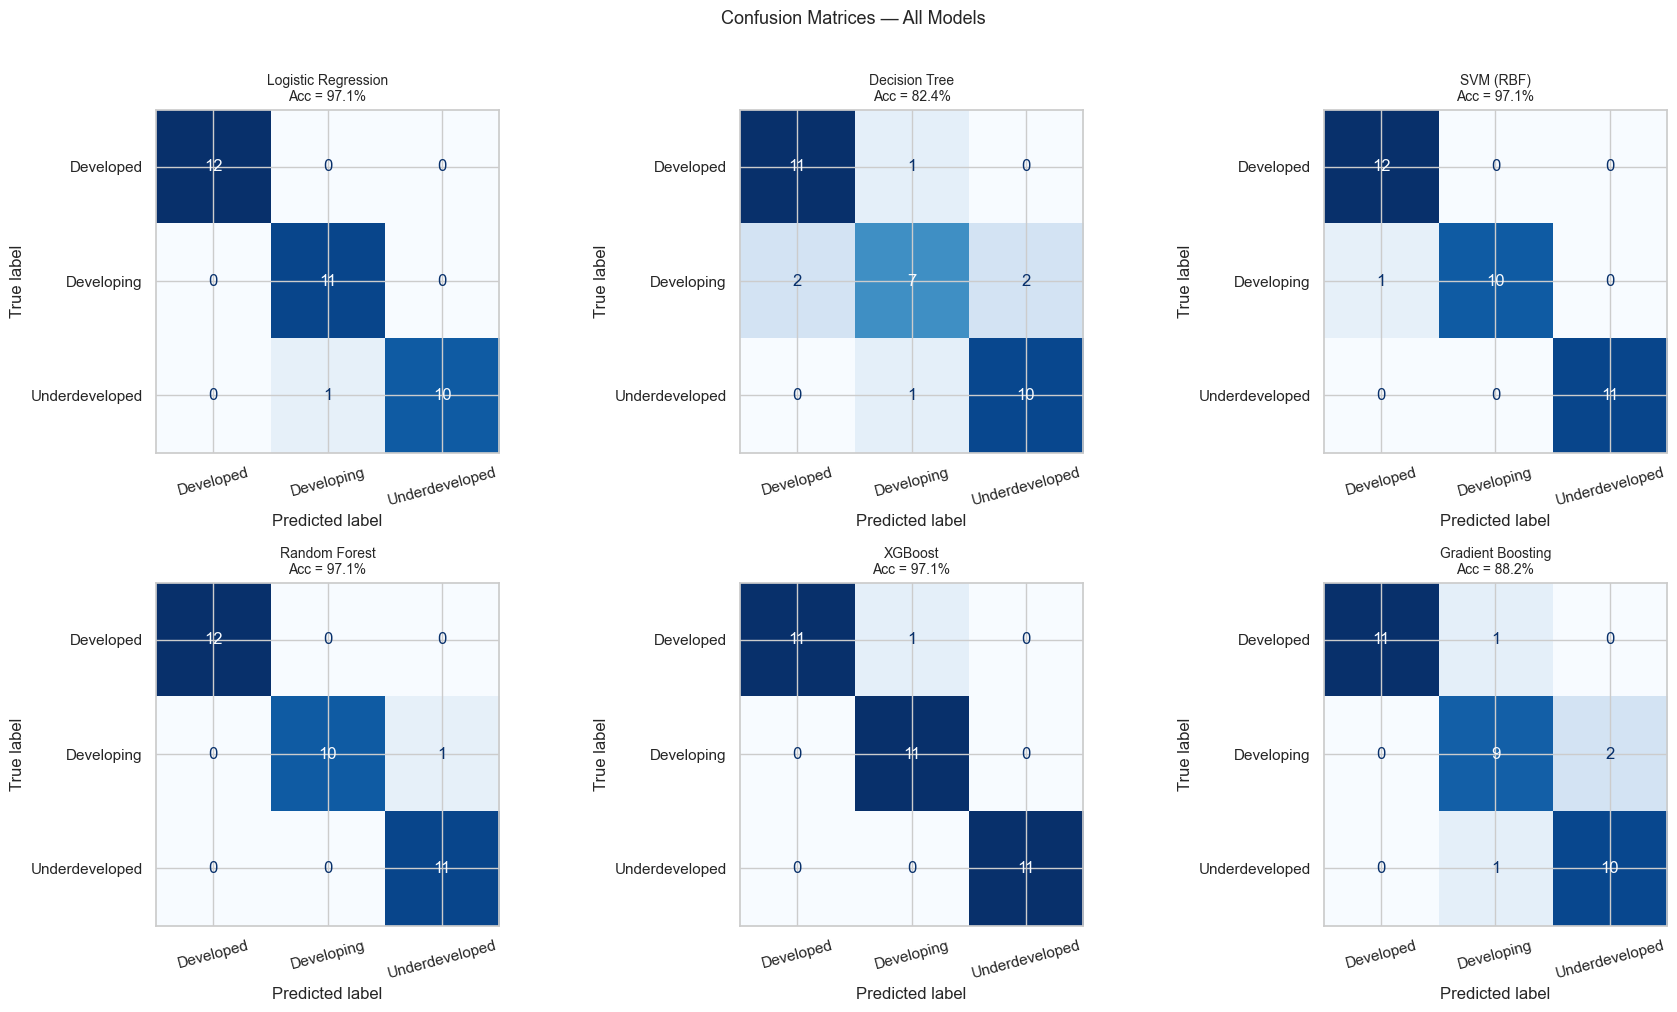

In [29]:
model_names = ['Logistic Regression','Decision Tree','SVM (RBF)',
               'Random Forest','XGBoost','Gradient Boosting']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, name in zip(axes.flatten(), model_names):
    cm = confusion_matrix(y_te, clf_results[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    acc = clf_results[name]['acc']
    ax.set_title(f"{name}\nAcc = {acc*100:.1f}%", fontsize=10)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 19) ROC-AUC Curves (Multi-class One-vs-Rest)

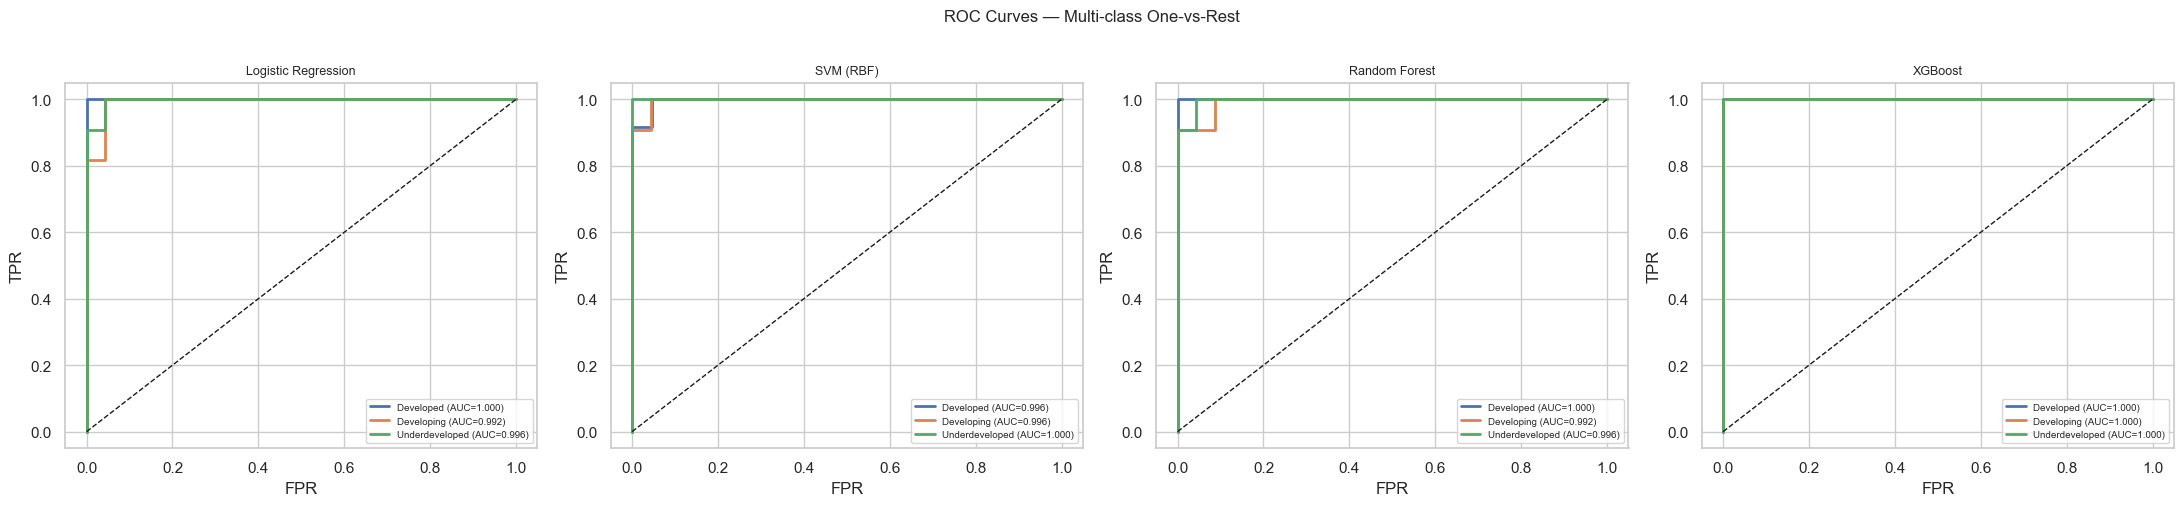

In [30]:
y_te_bin = label_binarize(y_te, classes=[0, 1, 2])

roc_models = ['Logistic Regression','SVM (RBF)','Random Forest','XGBoost']
fig, axes  = plt.subplots(1, 4, figsize=(22, 5))

for ax, name in zip(axes, roc_models):
    model = clf_results[name]['model']
    y_prob = model.predict_proba(X_te)
    for i, cls in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob[:, i])
        auc = roc_auc_score(y_te_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, lw=2, label=f'{cls} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=7)

plt.suptitle('ROC Curves — Multi-class One-vs-Rest', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 20) Accuracy Comparison Chart

              Model Test Acc (%) CV Acc (%) CV Std (%)
Logistic Regression       97.06%     93.99%      5.39%
          SVM (RBF)       97.06%     94.58%      3.56%
            XGBoost       97.06%     95.20%      3.09%
      Random Forest       97.06%     94.62%      3.49%
  Gradient Boosting       88.24%     92.80%      3.63%
      Decision Tree       82.35%     92.80%      3.63%


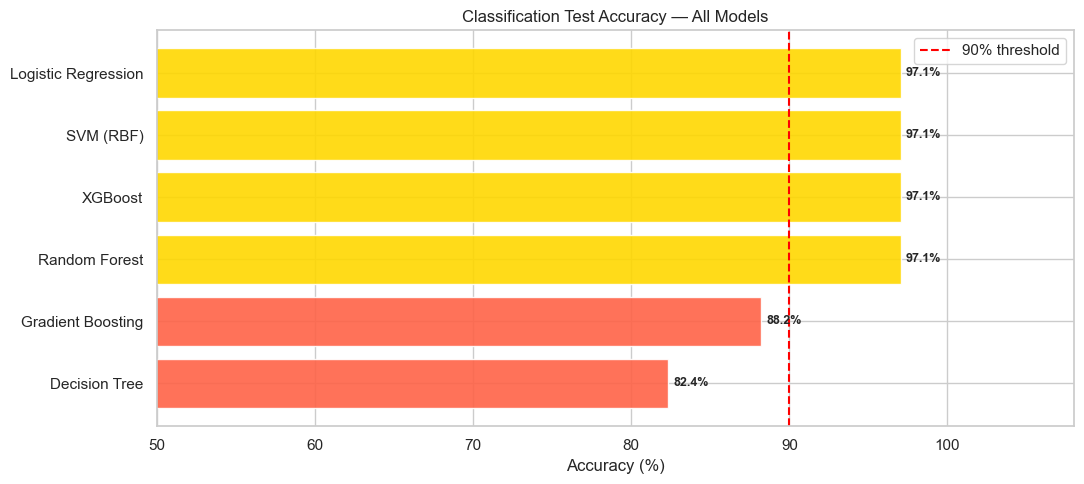

In [31]:
comp_df = pd.DataFrame([
    {'Model': n, 'Test Acc (%)': r['acc']*100,
     'CV Acc (%)': r['cv_mean']*100, 'CV Std (%)': r['cv_std']*100}
    for n, r in clf_results.items()
]).sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)

print(comp_df.to_string(index=False,
    formatters={'Test Acc (%)': '{:.2f}%'.format,
                'CV Acc (%)':   '{:.2f}%'.format,
                'CV Std (%)':   '{:.2f}%'.format}))

fig, ax = plt.subplots(figsize=(11, 5))
bar_c = ['gold' if a>=95 else ('steelblue' if a>=90 else 'tomato')
         for a in comp_df['Test Acc (%)']]
ax.barh(comp_df['Model'][::-1], comp_df['Test Acc (%)'][::-1],
        color=bar_c[::-1], edgecolor='white', alpha=0.9)
ax.axvline(90, color='red', ls='--', lw=1.5, label='90% threshold')
ax.set_title('Classification Test Accuracy — All Models')
ax.set_xlabel('Accuracy (%)')
ax.set_xlim(50, 108)
ax.legend()
for i, (_, row) in enumerate(comp_df[::-1].iterrows()):
    ax.text(row['Test Acc (%)']+0.3, i, f"{row['Test Acc (%)']:.1f}%",
            va='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()


## 21) Hyperparameter Tuning
### 21a) GridSearchCV — Random Forest

In [32]:
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators': [200, 300, 400],
        'max_depth':    [None, 10, 20],
        'max_features': ['sqrt', 'log2']
    },
    cv=skf, scoring='accuracy', n_jobs=-1
)
rf_gs.fit(X_tr, y_tr)

print(f"Best params : {rf_gs.best_params_}")
print(f"Best CV Acc : {rf_gs.best_score_*100:.2f}%")
y_rf_tuned = rf_gs.best_estimator_.predict(X_te)
print(f"Test Acc    : {accuracy_score(y_te, y_rf_tuned)*100:.2f}%")
print()
print(classification_report(y_te, y_rf_tuned, target_names=le.classes_))


Best params : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV Acc : 93.99%
Test Acc    : 94.12%

                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        12
    Developing       0.91      0.91      0.91        11
Underdeveloped       0.91      0.91      0.91        11

      accuracy                           0.94        34
     macro avg       0.94      0.94      0.94        34
  weighted avg       0.94      0.94      0.94        34



### 21b) RandomizedSearchCV — XGBoost

In [33]:
xgb_rs = RandomizedSearchCV(
    xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                      random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators':     sp_randint(200, 500),
        'max_depth':        sp_randint(3, 7),
        'learning_rate':    uniform(0.01, 0.14),
        'subsample':        uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
    },
    n_iter=25, cv=skf, scoring='accuracy',
    random_state=42, n_jobs=-1
)
xgb_rs.fit(X_tr, y_tr)

print(f"Best params : {xgb_rs.best_params_}")
print(f"Best CV Acc : {xgb_rs.best_score_*100:.2f}%")
y_xgb_tuned = xgb_rs.best_estimator_.predict(X_te)
print(f"Test Acc    : {accuracy_score(y_te, y_xgb_tuned)*100:.2f}%")
print()
print(classification_report(y_te, y_xgb_tuned, target_names=le.classes_))


c:\Users\Lenovo\Desktop\python_313\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:28:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params : {'colsample_bytree': np.float64(0.6571467271687763), 'learning_rate': np.float64(0.10112438621283941), 'max_depth': 3, 'n_estimators': 457, 'subsample': np.float64(0.8887995089067299)}
Best CV Acc : 94.67%
Test Acc    : 97.06%

                precision    recall  f1-score   support

     Developed       1.00      0.92      0.96        12
    Developing       0.92      1.00      0.96        11
Underdeveloped       1.00      1.00      1.00        11

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



## 22) Feature Importance

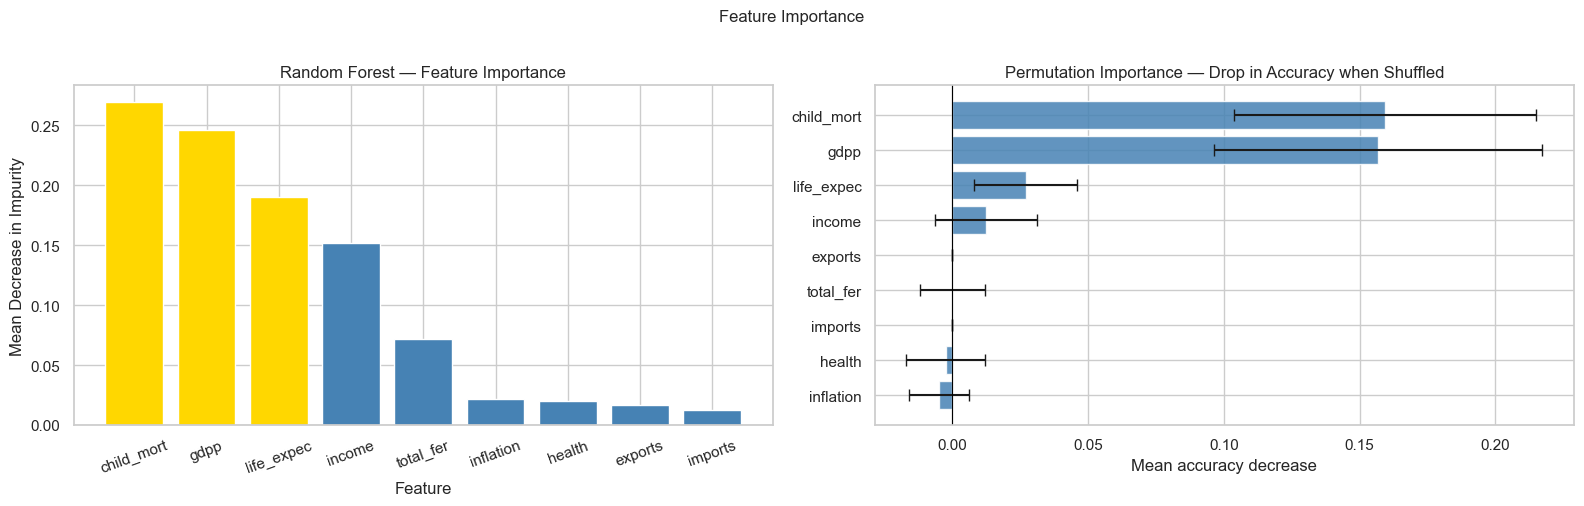

In [34]:
rf_best  = rf_gs.best_estimator_
fi_df    = pd.DataFrame({
    'Feature': numeric_cols,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(fi_df['Feature'], fi_df['Importance'],
            color=['gold' if i<3 else 'steelblue' for i in range(len(fi_df))],
            edgecolor='white')
axes[0].set_title('Random Forest — Feature Importance')
axes[0].set_xlabel('Feature'); axes[0].set_ylabel('Mean Decrease in Impurity')
axes[0].tick_params(axis='x', rotation=20)

# Permutation importance
perm = permutation_importance(rf_best, X_te, y_te,
                               n_repeats=12, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'Feature': numeric_cols,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

axes[1].barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
             xerr=perm_df['Std'][::-1], color='steelblue', edgecolor='white',
             alpha=0.85, capsize=4)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Permutation Importance — Drop in Accuracy when Shuffled')
axes[1].set_xlabel('Mean accuracy decrease')

plt.suptitle('Feature Importance', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 23) Final Summary

In [35]:
print("╔" + "═"*62 + "╗")
print("║  CLASSIFICATION ACCURACY SUMMARY                              ║")
print("╠" + "═"*62 + "╣")
print(f"║  {'Model':<32} {'Test Acc':>10} {'CV Acc':>10}  ║")
print("╠" + "─"*62 + "╣")
for _, row in comp_df.iterrows():
    tag = '✅' if row['Test Acc (%)'] >= 90 else '  '
    print(f"║  {tag} {row['Model']:<30} {row['Test Acc (%)']:>9.2f}% {row['CV Acc (%)']:>9.2f}%  ║")
print("╠" + "═"*62 + "╣")
rf_ta  = accuracy_score(y_te, y_rf_tuned)
xgb_ta = accuracy_score(y_te, y_xgb_tuned)
print(f"║  ✅ {'Random Forest (GridSearch Tuned)':<30} {rf_ta*100:>9.2f}%              ║")
print(f"║  ✅ {'XGBoost (RandomSearch Tuned)':<30} {xgb_ta*100:>9.2f}%              ║")
print("╚" + "═"*62 + "╝")
print()
print("╔" + "═"*52 + "╗")
print("║  CLUSTERING SUMMARY                                  ║")
print("╠" + "═"*52 + "╣")
_sil3 = silhouette_score(X_scaled, country_df['kmeans_cluster'])
print(f"║  K-Means (k=3) Silhouette Score : {_sil3:.4f}               ║")
for tier in _tier_names:
    n = (country_df['cluster_label'] == tier).sum()
    print(f"║  {tier:<35}: {n} countries  ║")
print("╚" + "═"*52 + "╝")


╔══════════════════════════════════════════════════════════════╗
║  CLASSIFICATION ACCURACY SUMMARY                              ║
╠══════════════════════════════════════════════════════════════╣
║  Model                              Test Acc     CV Acc  ║
╠──────────────────────────────────────────────────────────────╣
║  ✅ Logistic Regression                97.06%     93.99%  ║
║  ✅ SVM (RBF)                          97.06%     94.58%  ║
║  ✅ XGBoost                            97.06%     95.20%  ║
║  ✅ Random Forest                      97.06%     94.62%  ║
║     Gradient Boosting                  88.24%     92.80%  ║
║     Decision Tree                      82.35%     92.80%  ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ Random Forest (GridSearch Tuned)     94.12%              ║
║  ✅ XGBoost (RandomSearch Tuned)       97.06%              ║
╚══════════════════════════════════════════════════════════════╝

╔════════════════════════════════════════════════════